# Alaska Aviation Facilities Analysis with Python
### This project explores aviation facility data for Alaska using Python and Pandas. The analysis examines facility types,identifies seaplane bases, ranks facilities by airport reference point elevation, and calculates basic elevation statistics.

### Tools: Python, Pandas, Jupyter Notebook, Microsoft Excel 
### Dataset: Alaska aviation facilities data 
### Focus: Spreadsheet analysis, filtering, sorting, aggregation, and data export

In [1]:
import pandas as pd
df_facilities = pd.read_excel('Airport_Data.xlsx')

In [2]:
df_facilities.head()

,SiteNumber,Type,LocationID,EffectiveDate,Region,DistrictOffice,State,StateName,County,CountyState,...,AirportPositionSource,AirportPositionSourceDate,AirportElevationSource,AirportElevationSourceDate,ContractFuelAvailable,TransientStorage,OtherServices,WindIndicator,IcaoIdentifier,BeaconSchedule2
0,50009.*A,AIRPORT,'ADK,3/30/2017,AAL,NONE,AK,ALASKA,ALEUTIANS WEST,AK,...,3RD PARTY SURVEY,00:00:00,3RD PARTY SURVEY,00:00:00,NaN,HGR,CARGO,Y,PADK,SS-SR
1,50016.1*A,AIRPORT,'AKK,3/30/2017,AAL,NONE,AK,ALASKA,KODIAK ISLAND,AK,...,NACO,00:00:00,NACO,00:00:00,NaN,NaN,NaN,Y,PAKH,NaN
2,50017.*A,AIRPORT,'Z13,3/30/2017,AAL,NONE,AK,ALASKA,BETHEL,AK,...,STATE,00:00:00,STATE,00:00:00,NaN,NaN,CARGO,Y-L,NaN,SEE RMK
3,50017.1*C,SEAPLANE BASE,'KKI,3/30/2017,AAL,NONE,AK,ALASKA,BETHEL,AK,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN
4,50020.*A,AIRPORT,'AKI,3/30/2017,AAL,NONE,AK,ALASKA,BETHEL,AK,...,STATE,00:00:00,STATE,00:00:00,NaN,NaN,CARGO,Y-L,PFAK,SS-SR


## Dataset Overview

In [3]:
df_facilities.shape

(751, 103)

In [15]:
df_facilities.info()

<class 'pandas.DataFrame'>
RangeIndex: 751 entries, 0 to 750
Columns: 103 entries, SiteNumber to BeaconSchedule2
dtypes: float64(22), int64(1), object(5), str(75)
memory usage: 905.6+ KB


In [16]:
df_facilities["Type"].value_counts()

Type
AIRPORT          561
SEAPLANE BASE    138
HELIPORT          52
Name: count, dtype: int64

## Aviation Facility Types

In [4]:
df_facilities["Type"]

0            AIRPORT
1            AIRPORT
2            AIRPORT
3      SEAPLANE BASE
4            AIRPORT
           ...      
746    SEAPLANE BASE
747          AIRPORT
748          AIRPORT
749    SEAPLANE BASE
750          AIRPORT
Name: Type, Length: 751, dtype: str

In [5]:
df_facilities["Type"].unique()

<ArrowStringArray>
['AIRPORT', 'SEAPLANE BASE', 'HELIPORT']
Length: 3, dtype: str

## Seaplane Base Analysis

In [6]:
df_facilities["Type"] == "SEAPLANE BASE"

0      False
1      False
2      False
3       True
4      False
       ...  
746     True
747    False
748    False
749     True
750    False
Name: Type, Length: 751, dtype: bool

In [7]:
df_facilities[df_facilities["Type"] == "SEAPLANE BASE"]

,SiteNumber,Type,LocationID,EffectiveDate,Region,DistrictOffice,State,StateName,County,CountyState,...,AirportPositionSource,AirportPositionSourceDate,AirportElevationSource,AirportElevationSourceDate,ContractFuelAvailable,TransientStorage,OtherServices,WindIndicator,IcaoIdentifier,BeaconSchedule2
3,50017.1*C,SEAPLANE BASE,'KKI,3/30/2017,AAL,NONE,AK,ALASKA,BETHEL,AK,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN
5,50022.*C,SEAPLANE BASE,'KQA,3/30/2017,AAL,NONE,AK,ALASKA,ALEUTIANS EAST,AK,...,STATE,00:00:00,STATE,00:00:00,NaN,NaN,NaN,Y,NaN,NaN
8,50027.52*C,SEAPLANE BASE,'Z33,3/30/2017,AAL,NONE,AK,ALASKA,BRISTOL BAY,AK,...,NaN,NaN,NaN,NaN,NaN,TIE,NaN,NaN,NaN,NaN
15,50031.5*C,SEAPLANE BASE,'AK81,3/30/2017,AAL,NONE,AK,ALASKA,KODIAK ISLAND,AK,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN
24,50035.2*C,SEAPLANE BASE,'3C3,3/30/2017,AAL,NONE,AK,ALASKA,ANCHORAGE,AK,...,OWNER,00:00:00,OWNER,00:00:00,NaN,NaN,NaN,Y,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
725,50877.32*C,SEAPLANE BASE,'MFN,3/30/2017,AAL,NONE,AK,ALASKA,MATANUSKA-SUSITNA,AK,...,OWNER,00:00:00,OWNER,00:00:00,NaN,NaN,NaN,NaN,NaN,NaN
734,50877.01*C,SEAPLANE BASE,'2X2,3/30/2017,AAL,NONE,AK,ALASKA,MATANUSKA-SUSITNA,AK,...,FAA-EST,00:00:00,STATE,00:00:00,NaN,TIE,CHTR,Y,NaN,NaN
737,50905.*C,SEAPLANE BASE,'68A,3/30/2017,AAL,NONE,AK,ALASKA,WRANGELL-PETERSBURG,AK,...,NaN,NaN,NaN,NaN,NaN,NaN,CARGO,Y,NaN,NaN
746,50920.12*C,SEAPLANE BASE,'2Y3,3/30/2017,AAL,NONE,AK,ALASKA,SKAGWAY-YAKUTAT,AK,...,FAA-EST,00:00:00,NaN,NaN,NaN,TIE,CARGO,NaN,NaN,NaN


## Top 5 highest aviation facilities in Alaska

In [8]:
df_facilities.sort_values(by = "ARPElevation", ascending = False)

,SiteNumber,Type,LocationID,EffectiveDate,Region,DistrictOffice,State,StateName,County,CountyState,...,AirportPositionSource,AirportPositionSourceDate,AirportElevationSource,AirportElevationSourceDate,ContractFuelAvailable,TransientStorage,OtherServices,WindIndicator,IcaoIdentifier,BeaconSchedule2
584,50739.1*A,AIRPORT,'AA09,3/30/2017,AAL,NONE,AK,ALASKA,MATANUSKA-SUSITNA,AK,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y,NaN,NaN
630,50738.20*A,AIRPORT,'93AK,3/30/2017,AAL,NONE,AK,ALASKA,MATANUSKA-SUSITNA,AK,...,OWNER,00:00:00,OWNER,00:00:00,NaN,NaN,CARGO,Y,NaN,NaN
265,50324.6*A,AIRPORT,'4Z5,3/30/2017,AAL,NONE,AK,ALASKA,SOUTHEAST FAIRBANKS,AK,...,FAA OE/AAA,00:00:00,FAA OE/AAA,00:00:00,NaN,NaN,NaN,Y,NaN,NaN
582,50738.01*A,AIRPORT,'2AK7,3/30/2017,AAL,NONE,AK,ALASKA,MATANUSKA-SUSITNA,AK,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
353,50439.18*A,AIRPORT,'AK80,3/30/2017,AAL,NONE,AK,ALASKA,MATANUSKA-SUSITNA,AK,...,OWNER,00:00:00,OWNER,00:00:00,NaN,NaN,NaN,Y,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
749,50928.*C,SEAPLANE BASE,'78K,3/30/2017,AAL,NONE,AK,ALASKA,KETCHIKAN GATEWAY,AK,...,NaN,NaN,NaN,NaN,NaN,NaN,CARGO,N,NaN,NaN
261,50321.*C,SEAPLANE BASE,'OOH,3/30/2017,AAL,NONE,AK,ALASKA,SKAGWAY-YAKUTAT,AK,...,NaN,NaN,NaN,NaN,NaN,TIE,NaN,Y,NaN,NaN
289,50385.06*H,HELIPORT,'73AK,3/30/2017,AAL,NONE,AK,ALASKA,ALEUTIAN ISLANDS,AK,...,OWNER,00:00:00,OWNER,00:00:00,NaN,NaN,NaN,Y,NaN,NaN
714,50873.3*C,SEAPLANE BASE,'KWP,3/30/2017,AAL,NONE,AK,ALASKA,KODIAK ISLAND,AK,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN


In [9]:
df_facilities.sort_values(by = "ARPElevation", ascending = False).head(n = 5)

,SiteNumber,Type,LocationID,EffectiveDate,Region,DistrictOffice,State,StateName,County,CountyState,...,AirportPositionSource,AirportPositionSourceDate,AirportElevationSource,AirportElevationSourceDate,ContractFuelAvailable,TransientStorage,OtherServices,WindIndicator,IcaoIdentifier,BeaconSchedule2
584,50739.1*A,AIRPORT,'AA09,3/30/2017,AAL,NONE,AK,ALASKA,MATANUSKA-SUSITNA,AK,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y,NaN,NaN
630,50738.20*A,AIRPORT,'93AK,3/30/2017,AAL,NONE,AK,ALASKA,MATANUSKA-SUSITNA,AK,...,OWNER,00:00:00,OWNER,00:00:00,NaN,NaN,CARGO,Y,NaN,NaN
265,50324.6*A,AIRPORT,'4Z5,3/30/2017,AAL,NONE,AK,ALASKA,SOUTHEAST FAIRBANKS,AK,...,FAA OE/AAA,00:00:00,FAA OE/AAA,00:00:00,NaN,NaN,NaN,Y,NaN,NaN
582,50738.01*A,AIRPORT,'2AK7,3/30/2017,AAL,NONE,AK,ALASKA,MATANUSKA-SUSITNA,AK,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
353,50439.18*A,AIRPORT,'AK80,3/30/2017,AAL,NONE,AK,ALASKA,MATANUSKA-SUSITNA,AK,...,OWNER,00:00:00,OWNER,00:00:00,NaN,NaN,NaN,Y,NaN,NaN


## Elevation Analysis

In [10]:
df_facilities["ARPElevation"].mean()

np.float64(425.93209054593876)

### i) Highest elevation 

In [11]:
df_facilities["ARPElevation"].max()

np.int64(3984)

### ii) Lowest elevation 

In [12]:
df_facilities["ARPElevation"].min()

np.int64(0)

In [13]:
df_seaplane = df_facilities[df_facilities["Type"] == "SEAPLANE BASE"]

In [14]:
df_seaplane.to_excel("./seaplane.xlsx")

## Exploratory Data Visualizations

### 1. Distribution of Aviation Facility Types

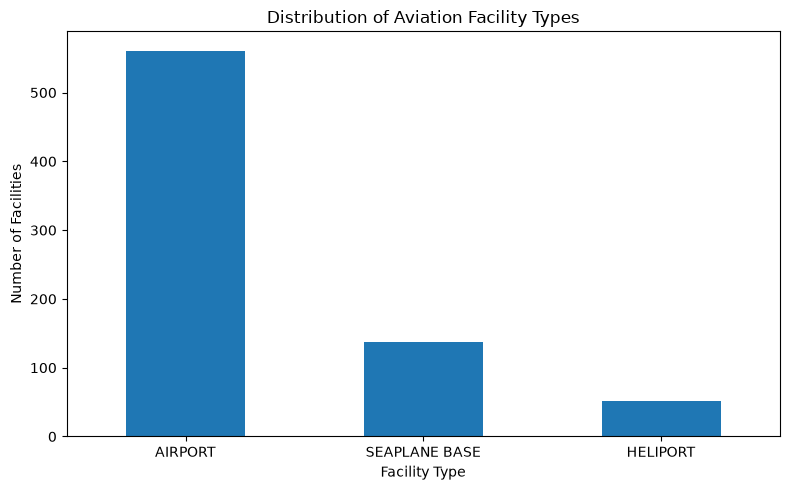

In [18]:
import matplotlib.pyplot as plt

facility_counts = df_facilities["Type"].value_counts()
plt.figure(figsize=(8, 5))
facility_counts.plot(kind="bar")

plt.title("Distribution of Aviation Facility Types")
plt.xlabel("Facility Type")
plt.ylabel("Number of Facilities")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### 2. Top 5 Aviation Facilities by Elevation

In [21]:
top_5_elevation = (
    df_facilities[["LocationID", "Type", "ARPElevation"]]
    .dropna(subset=["ARPElevation"])
    .sort_values("ARPElevation", ascending=False)
    .head(5)
)
top_5_elevation

,LocationID,Type,ARPElevation
584,'AA09,AIRPORT,3984
630,'93AK,AIRPORT,3720
265,'4Z5,AIRPORT,3620
582,'2AK7,AIRPORT,3600
353,'AK80,AIRPORT,3530


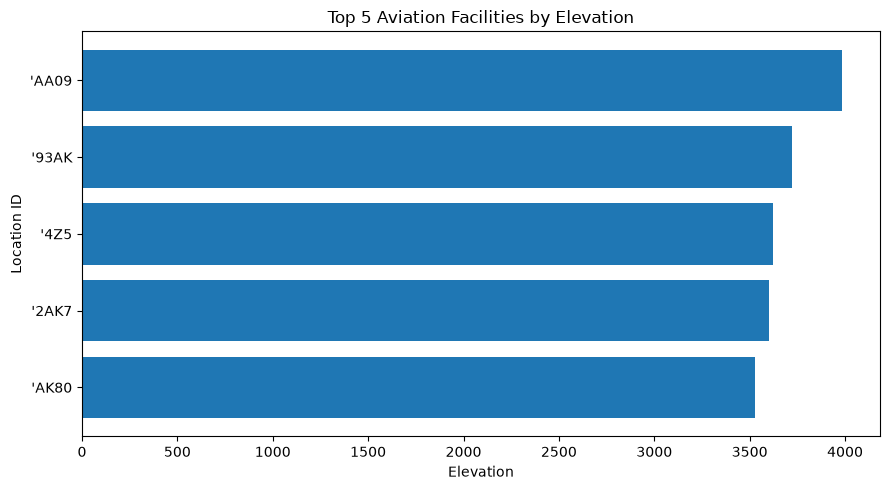

In [22]:
plt.figure(figsize=(9, 5))

plt.barh(
    top_5_elevation["LocationID"].astype(str),
    top_5_elevation["ARPElevation"]
)

plt.title("Top 5 Aviation Facilities by Elevation")
plt.xlabel("Elevation")
plt.ylabel("Location ID")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### 3. Distribution of Aviation Facility Elevations

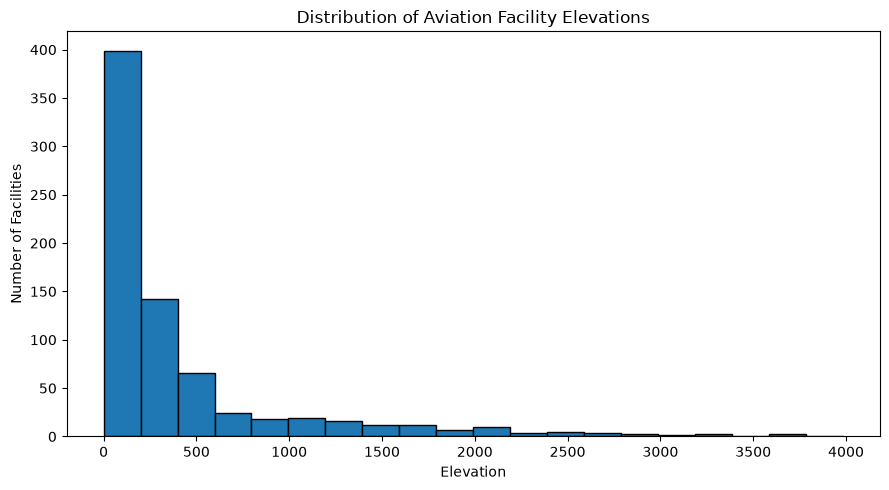

In [19]:
elevation_data = df_facilities["ARPElevation"].dropna()

plt.figure(figsize=(9, 5))

plt.hist(
    elevation_data,
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of Aviation Facility Elevations")
plt.xlabel("Elevation")
plt.ylabel("Number of Facilities")

plt.tight_layout()
plt.show()

##   Key Findings
## • The dataset contains 751 aviation facilities across Alaska.
## • Airports are the dominant facility type, with 561 facilities.
## • Alaska also contains 138 seaplane bases and 52 heliports in the dataset.
## • The average aviation facility elevation is approximately 425.93.
## • Facility elevations range from 0 to 3,984.
## • The five highest-elevation facilities are all classified as airports.